# Tutorial 11: Semantic Segmentation using Pre-Trained Model (DeepLabV3+)

### Cell 1: Imports and Device Setup

In [1]:
import torch
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Cell 2: Configuration and Pascal VOC Helpers

In [2]:
# Pascal VOC class labels
voc_labels = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def decode_segmentation(mask, num_classes=21):
    colors = np.array([
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128], 
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0], 
        [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128], 
        [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ])
    r, g, b = np.zeros_like(mask), np.zeros_like(mask), np.zeros_like(mask)
    for cls in range(num_classes):
        idx = mask == cls
        r[idx], g[idx], b[idx] = colors[cls]
    return np.stack([r, g, b], axis=2)

# Preprocessing pipeline used by both models
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Cell 3: Initializing Models

In [11]:
# Task 1: Load DeepLabV3+
seg_model = models.segmentation.deeplabv3_resnet101(weights='DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1').to(device)
seg_model.eval()

# Task 2: Load Mask R-CNN
mask_model = models.detection.maskrcnn_resnet50_fpn(weights='MaskRCNN_ResNet50_FPN_Weights.DEFAULT').to(device)
mask_model.eval()

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\M.T/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100.0%


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

### Cell 4: Dataset Path 

In [13]:
image_path = r"C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\dog.jpeg"

image_files = [image_path]
print(f"Selected Image: {os.path.basename(image_path)}")

Selected Image: dog.jpeg


### Cell 5: Define the Inference 

In [16]:
def run_segmentation_pipeline(img_path, s_model, m_model, device):
    # Load and preprocess
    orig_img = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(orig_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Task 1: Semantic Segmentation
        seg_output = s_model(input_tensor)['out'][0]
        seg_preds = seg_output.argmax(0).cpu().numpy()
        seg_map = decode_segmentation(seg_preds)
        
        # Task 2: Instance Segmentation (Mask R-CNN)
        mask_output = m_model(input_tensor)[0]
        masks = mask_output['masks'].cpu().numpy()
        scores = mask_output['scores'].cpu().numpy()
        
        # Combine high-confidence masks (threshold > 0.6)
        combined_mask = np.zeros(masks.shape[2:])
        for i, score in enumerate(scores):
            if score > 0.6:
                combined_mask = np.maximum(combined_mask, masks[i][0])
                
    return orig_img, seg_map, combined_mask, seg_preds



### Cell 6: Visualization Logic

In [17]:
def plot_results(img_path, orig_img, seg_map, combined_mask, seg_preds):
    plt.figure(figsize=(18, 6))
    
    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(orig_img)
    plt.title(f"Original: {os.path.basename(img_path)}")
    plt.axis('off')
    
    # DeepLabV3+ Result (Task 1)
    plt.subplot(1, 3, 2)
    plt.imshow(seg_map)
    plt.title("DeepLabV3+ (Semantic)")
    plt.axis('off')
    
    # Mask R-CNN Result (Task 2)
    plt.subplot(1, 3, 3)
    plt.imshow(orig_img)
    plt.imshow(combined_mask > 0.5, alpha=0.5, cmap='jet')
    plt.title("Mask R-CNN (Instance)")
    plt.axis('off')
    
    plt.show()
    
    # Task 3: Identify detected classes in the data
    detected_ids = np.unique(seg_preds)
    labels = [voc_labels[i] for i in detected_ids if i < len(voc_labels)]
    print(f"Detected Classes: {labels}")

### Cell 7: Execute the Loop

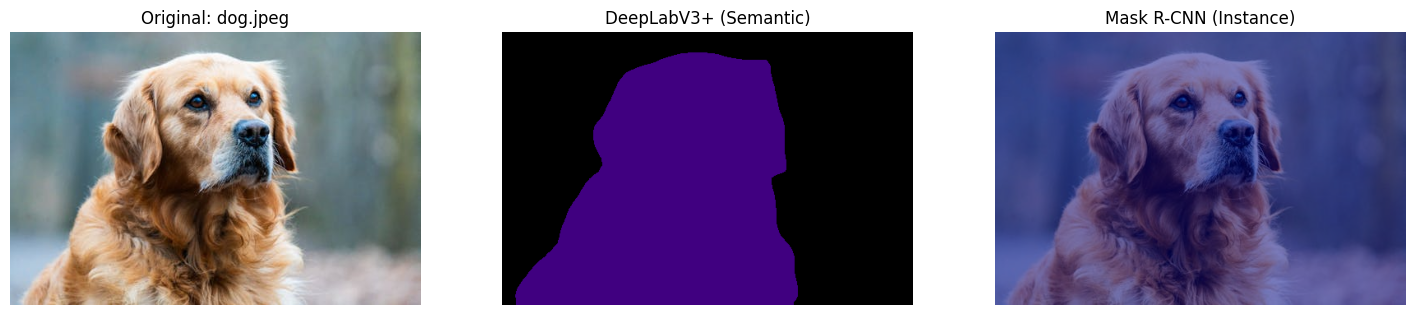

Detected Classes: ['background', 'dog']


In [18]:
# Run the pipeline for the image
orig, smap, imask, preds = run_segmentation_pipeline(image_path, seg_model, mask_model, device)

# Plot the final visual results
plot_results(image_path, orig, smap, imask, preds)